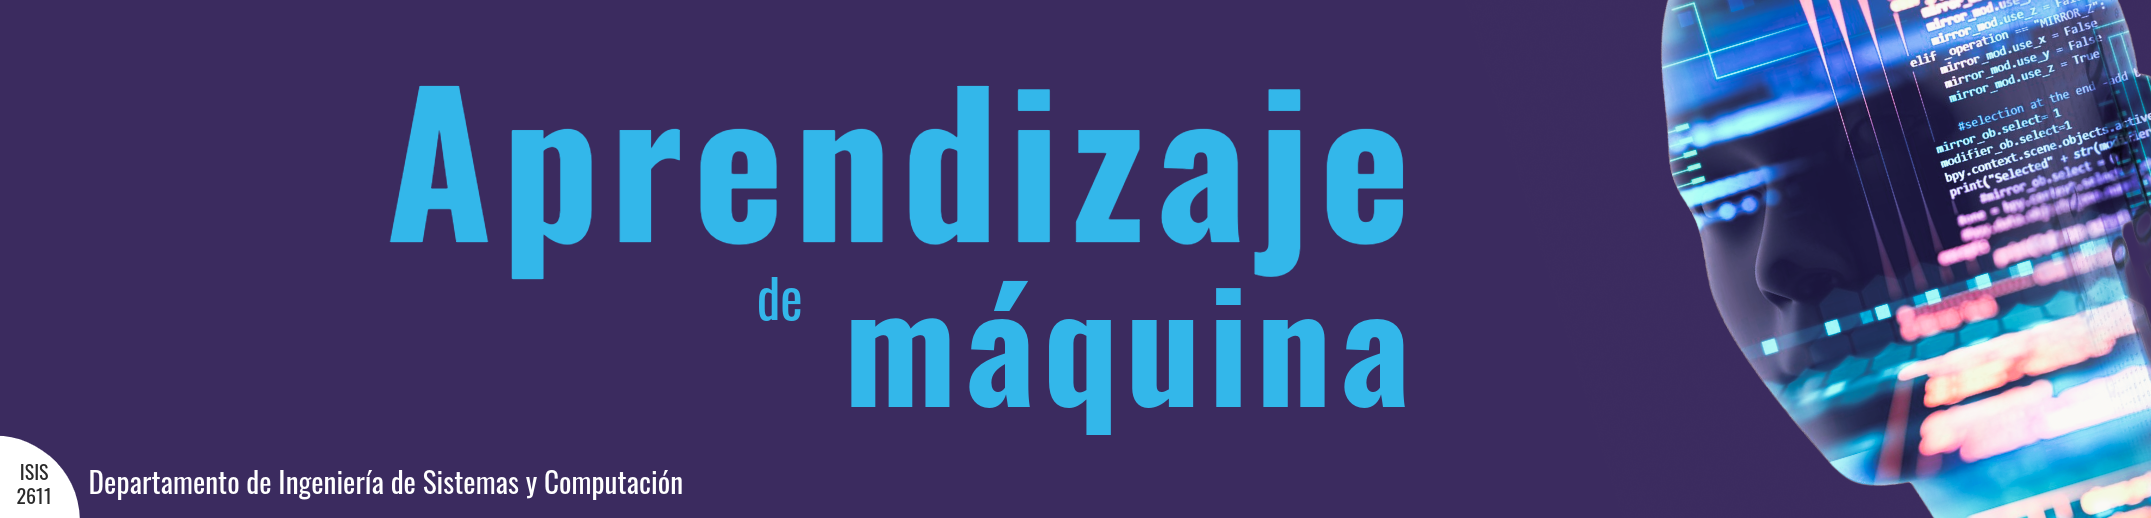

# Bosques Aleatorios, KNN, y SMOTE

Esta práctica profundiza en el uso de los árboles de decisión para tareas de clasificación, enfocándose en cómo su implementación en ensambles, conocida como **Bosques Aleatorios**, permite obtener modelos con mayor capacidad de generalización. Asimismo, se introduce el clasificador KNN (K-Nearest Neighbors), el cual es capaz de generar fronteras de decisión complejas y tolerantes al ruido a través de un algoritmo notablemente sencillo. Finalmente, se explora la técnica SMOTE [(Synthetic Minority Over-sampling Technique)](https://arxiv.org/abs/1106.1813), orientada a mejorar el rendimiento en conjuntos de datos altamente desbalanceados, donde el sesgo hacia la clase mayoritaria suele dificultar el aprendizaje.

En esta ocasión se utilizará el conjunto de Mandelbrot $(M)$, un fractal bidimensional de gran relevancia en la dinámica holomorfa. Formalmente, $M$ se define en el plano complejo como el conjunto de parámetros $c \in \mathbb{C}$ para los cuales la secuencia recursiva $z_{n+1}=z_n^2+c$, con valor inicial $z_0 = 0$, permanece acotada. Su definición matemática es:
$$
M=\{c \in \mathbb{C} \, | \, ∀n∈N: |z_n|≤2\}
$$

Para ello, se comenzará con la construcción del conjunto de Mandelbrot, del cual se obtendrá un subconjunto de puntos distribuidos aleatoriamente. Estos datos se utilizarán para entrenar y evaluar los distintos algoritmos de clasificación que se usarán en esta práctica, permitiendo determinar qué tan fielmente pueden representar estos modelos una estructura geométrica de alta complejidad no lineal.

La metodología se desarrollará en las siguientes etapas: Construcción y exploración del conjunto, preprocesamiento, construcción de pipelines para cada modelo, optimización de hiperparámetros y, finalmente, evaluación del desempeño.


Para ello este notebook se divide en:

1. Importación de librerías
2. Construcción del conjunto.
3. Exploración del conjunto.
4. Partición de los datos.
5. Construcción y Evaulación de los pipelines.
  - 5.1. Árbol de decisión
  - 5.2. Bosque Aleatorio.
  - 5.3. KNN.
  - 5.4. SMOTE.
6. Persistencia del pipeline.
7. Ejercicios


## 1. Importación de librerías


In [67]:
import joblib
import numpy as np
import pandas as pd

from matplotlib import patches
from matplotlib import pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## 2. Construcción del conjunto


Como se comentó en la introducción de esta práctica, el conjunto de Mandelbrot está compuesto por los números $c \in \mathbb{C}$ para los que la secuencia $z_{n+1}=z_n^2+c$ se mantiene acotada, es decir $|z_n| \leq 2$. Por lo que la forma más sencilla de construir este conjunto es creando una malla que contiene los valores de $c$, para luego utilizar la definición de la secuencia y revisar en qué casos esta diverje. Para ello se crea la siguiente función:

In [3]:
def generate_mandelbrot(width, height, Re_range, Im_range, max_iter):
    # Se crea una malla con los números complejos c
    Re_linspace = np.linspace(Re_range[0], Re_range[1], width)
    Im_linspace = np.linspace(Im_range[0], Im_range[1], height)
    Re, Im = np.meshgrid(Re_linspace, Im_linspace)
    C = Re + 1j * Im

    # Se inicializa la secuencia de cada número c en 0
    Z = np.zeros_like(C)

    # Adicionalmente, se crea una máscara booleana para llevar traza
    # de los números c que aún no divergen
    mask = np.ones_like(Z, dtype=bool)

    # Finalmente, se crea un contador por cada número c que llevará
    # cuenta del número de iteraciones que le toma a la secuencia
    # para diverger
    fractal = np.zeros(C.shape, dtype=int)

    # Se itera aplicando la secuencia únicamente sobre los valores de
    # c que aún no divergen
    for i in range(max_iter):
        mask[mask] = np.abs(Z[mask]) <= 2
        Z[mask] = Z[mask]**2 + C[mask]

        fractal[mask] += 1

    # Se retorna la máscara con los valores de c que no llegaron a
    # diverger y el contador del número de iteraciones que cada c alcanzó
    # sin diverger
    return mask, fractal

## 3. Exploración del conjunto de datos


Con el fin de verificar que la función que genera el conjunto de Mandelbrot es correcta, se grafica el conjunto completo:

In [4]:
w, h = 1000, 1000
Re_range = (-2.0, 0.5) # Rango de valores sobre los números reales
Im_range = (-1.25, 1.25) # Rango de valores sobre los números imaginarios
iterations = 150

mask, fractal = generate_mandelbrot(w, h, Re_range, Im_range, iterations)

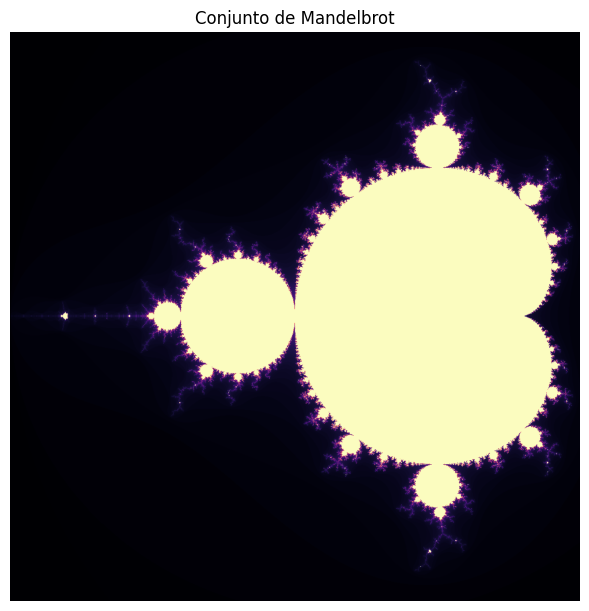

In [5]:
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

ax.imshow(fractal, extent=(Re_range[0], Re_range[1], Im_range[0], Im_range[1]), cmap='magma')
ax.set(title='Conjunto de Mandelbrot')
ax.axis('off')

plt.show()

Si bien la imagen anterior parece indicar que el conjunto ha sido representado correctamente, hay que recordar que este posee una geometría fractal. Por lo que, para determinar si este aspecto se representa correctamente, se toma una sección arbitraría y se amplía con el fin de explorarla.

In [6]:
w, h = 1000, 1000
Re_range_zoomed = (-0.8, -0.7)
Im_range_zoomed = (0.075, 0.175)
iterations = 150

_, fractal_zoomed = generate_mandelbrot(w, h, Re_range_zoomed, Im_range_zoomed, iterations)

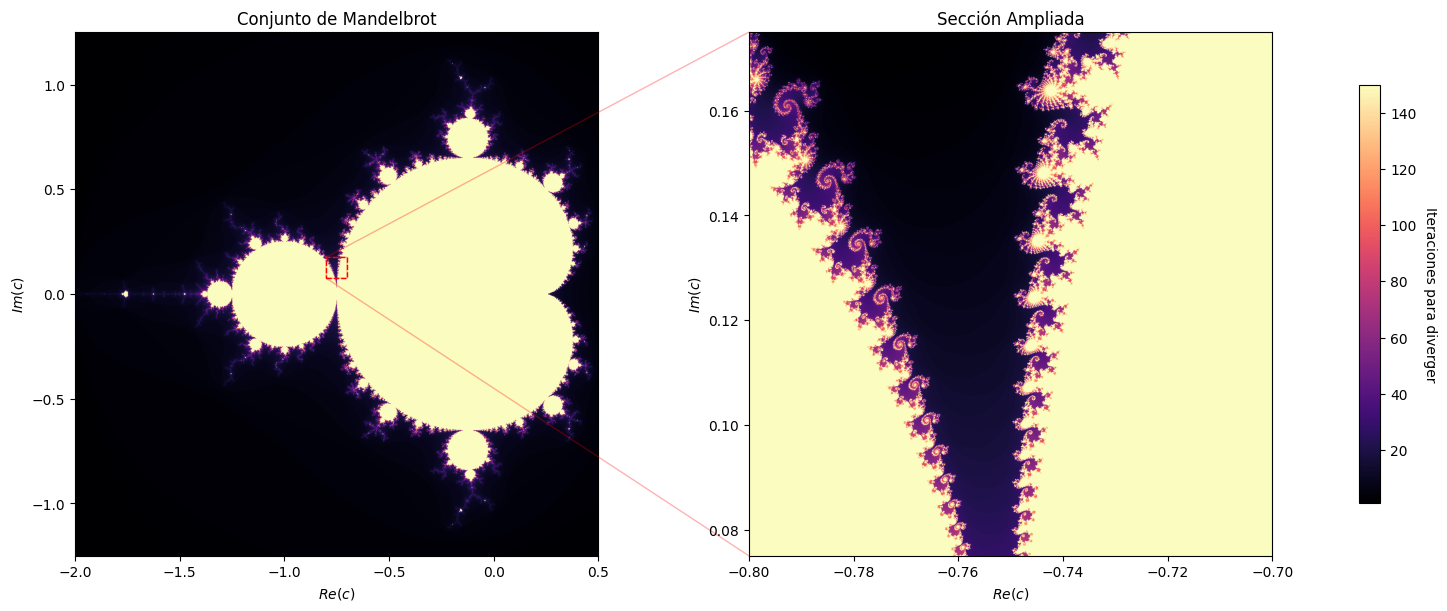

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

img = ax[0].imshow(fractal, extent=(Re_range[0], Re_range[1], Im_range[0], Im_range[1]), origin='lower', cmap='magma')

rect = patches.Rectangle((Re_range_zoomed[0], Im_range_zoomed[0]), Re_range_zoomed[1]-Re_range_zoomed[0], Im_range_zoomed[1]-Im_range_zoomed[0], linewidth=1, edgecolor='r', facecolor='none', linestyle='--')

ax[0].add_patch(rect)
ax[0].set(title='Conjunto de Mandelbrot', xlabel='$Re(c)$', ylabel='$Im(c)$')

ax[1].imshow(fractal_zoomed, extent=(Re_range_zoomed[0], Re_range_zoomed[1], Im_range_zoomed[0], Im_range_zoomed[1]), origin='lower', cmap='magma')
ax[1].set(title='Sección Ampliada', xlabel='$Re(c)$', ylabel='$Im(c)$')

ax[0].indicate_inset_zoom(ax[1], edgecolor="r", alpha=0.3)

cbar = fig.colorbar(img, ax=ax, location='right', shrink=0.8)
cbar.set_label('Iteraciones para diverger', rotation=270, labelpad=15)

plt.show()

En vista de que al ampliar secciones del conjunto se observa su naturaleza fractal, se puede tener certeza de que el conjunto se ha definido correctamente. Por lo que se procede a estudiar la distribución de los valores de $c$ que no llegaron a diverger. Para ello se usa de la máscara que se obtuvo del conjunto.

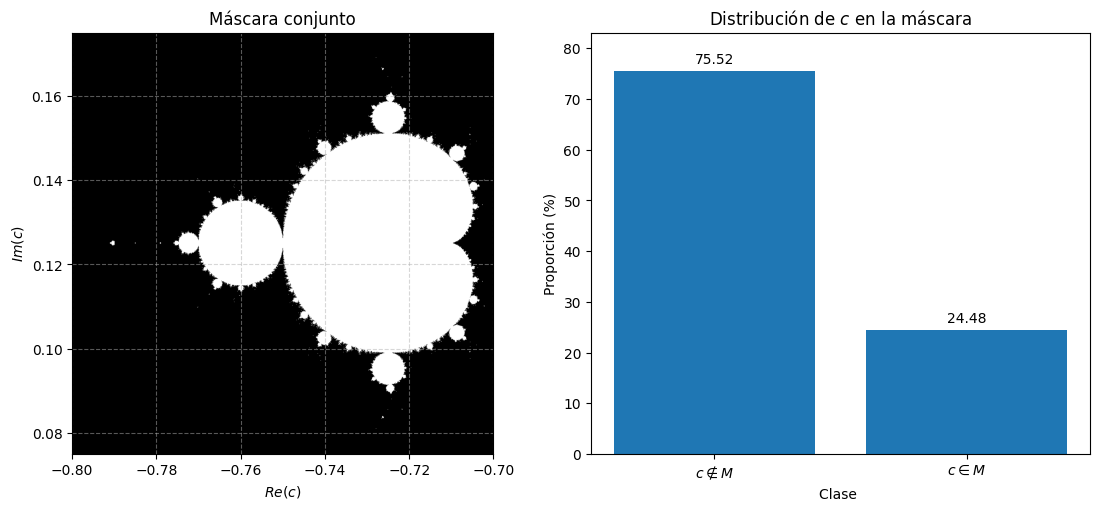

In [8]:
class_names = [r'$c \notin M$', r'$c \in M$']

_, class_counts = np.unique(mask, return_counts=True)
class_proportions = np.round(class_counts/np.sum(class_counts) * 100, 2)

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(11, 5))

ax[0].imshow(mask, extent=(Re_range_zoomed[0], Re_range_zoomed[1], Im_range_zoomed[0], Im_range_zoomed[1]), origin='lower', cmap='bone')
ax[0].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Máscara conjunto')
ax[0].grid(linestyle='--', alpha=0.5)

bars = ax[1].bar(class_names, class_proportions)
ax[1].bar_label(bars, padding=3)
ax[1].set(xlabel = 'Clase ', ylabel = 'Proporción (%)', title = 'Distribución de $c$ en la máscara', ylim=(0, max(class_proportions*1.1)))

plt.show()

Lo que se observa es que el conjunto de Mandelbrot por naturaleza es desbalanceado, con la mayoría de los valores de $c$ por fuera del conjunto.

## 4. Partición de los datos



Posteriormente, se realiza un muestreo aleatorio sobre la máscara de la región de interés. Para ello, la malla del conjunto se trata como una imagen donde cada píxel representa la pertenencia de $c$ al conjunto. El proceso de selección se ejecuta mediante la función `np.random.choice()`, la cual garantiza una distribución uniforme sobre el espacio de índices de los píxeles, permitiendo extraer una muestra representativa del tamaño deseado. Finalmente, se utiliza el parámetro `replace=False` para evitar duplicados.



In [9]:
total_pixels = w * h

num_points = 1500
mask_indices = np.random.choice(total_pixels, size=num_points, replace=False)

Una vez definidos los índices de la máscara, se reorganizan en el formato `[fila, columna]` para definir el conjunto $x$. El vector de etiquetas $y$ se obtiene al evaluar $x$ en la máscara del conjunto. Posteriormente, estos conjuntos se dividen en entrenamiento y prueba. Finalmente, con el objetivo de emular la naturaleza de un dataset real, sobre el conjunto de entrenamiento se aplica ruido normal para alterar la posición de los puntos y ruido uniforme sobre el $25\%$ de los puntos pertenecientes al conjunto de Mandelbrot para cambiar su etiqueta.

In [10]:
rows, cols = np.unravel_index(mask_indices, (h, w))
x_pixels = np.column_stack((cols, rows))

# Se cambia el rango de x_pixels, para regresar al rango del conjunto de Mandelbrot
x = np.zeros_like(x_pixels, dtype=float)
x[:, 0] = Re_range[0] + (x_pixels[:, 0] / (w - 1)) * (Re_range[1] - Re_range[0])
x[:, 1] = Im_range[0] + (x_pixels[:, 1] / (h - 1)) * (Im_range[1] - Im_range[0])

y = mask[x_pixels[:, 1], x_pixels[:, 0]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, stratify=y)

# Se altera la posición
x_train += np.random.normal(0, 0.25, x_train.shape)

x_train[:, 0] = np.clip(x_train[:, 0], a_min=Re_range[0], a_max=Re_range[1])
x_train[:, 1] = np.clip(x_train[:, 1], a_min=Im_range[0], a_max=Im_range[1])

# Se cambia la etiqueta
inside_points_indices = np.argwhere(y_train)

noise_probability = 0.3
num_noisy_points = int(len(inside_points_indices)*noise_probability)

noisy_points_indices = np.random.choice(len(inside_points_indices), size=num_noisy_points, replace=False)

y_train[inside_points_indices[noisy_points_indices]] = ~y_train[inside_points_indices[noisy_points_indices]]


Tras finalizar este proceso, se procede a visualizar los conjuntos resultates.

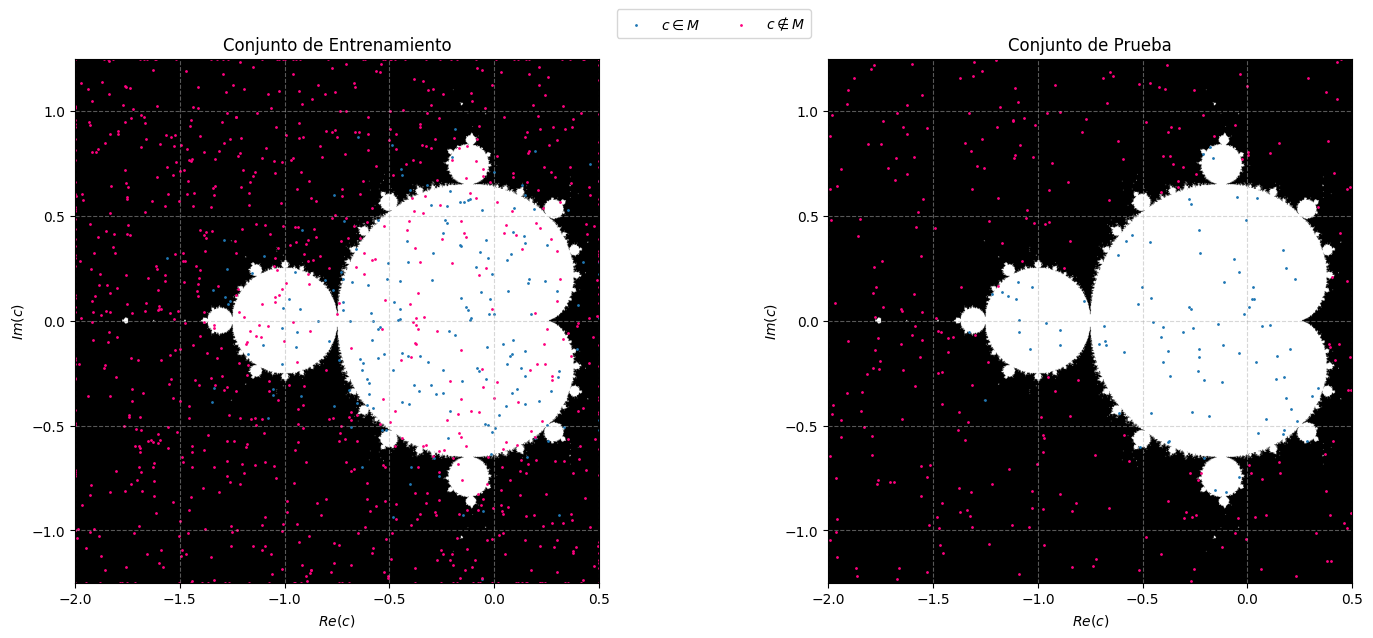

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

ax[0].imshow(mask, extent=(Re_range[0], Re_range[1], Im_range[0], Im_range[1]), origin='lower', cmap='bone')
ax[0].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Conjunto de Entrenamiento')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].scatter(x_train[y_train, 0], x_train[y_train, 1], s=1, label=r'$c \in M$')
ax[0].scatter(x_train[~y_train, 0], x_train[~y_train, 1], s=1, c='#FF007F', label=r'$c \notin M$')

ax[1].imshow(mask, extent=(Re_range[0], Re_range[1], Im_range[0], Im_range[1]), origin='lower', cmap='bone')
ax[1].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Conjunto de Prueba')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].scatter(x_test[y_test, 0], x_test[y_test, 1], s=1, label=r'$c \in M$')
ax[1].scatter(x_test[~y_test, 0], x_test[~y_test, 1], s=1, c='#FF007F', label=r'$c \notin M$')

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

plt.show()

Al inspeccionar los datos, se verifica que el muestreo y la generación de ruido fueron exitosos.

Finalmente, se revisan las distribuciones resultantes sobre los conjuntos en los que los modelos van a ser entrenados y evaluados.

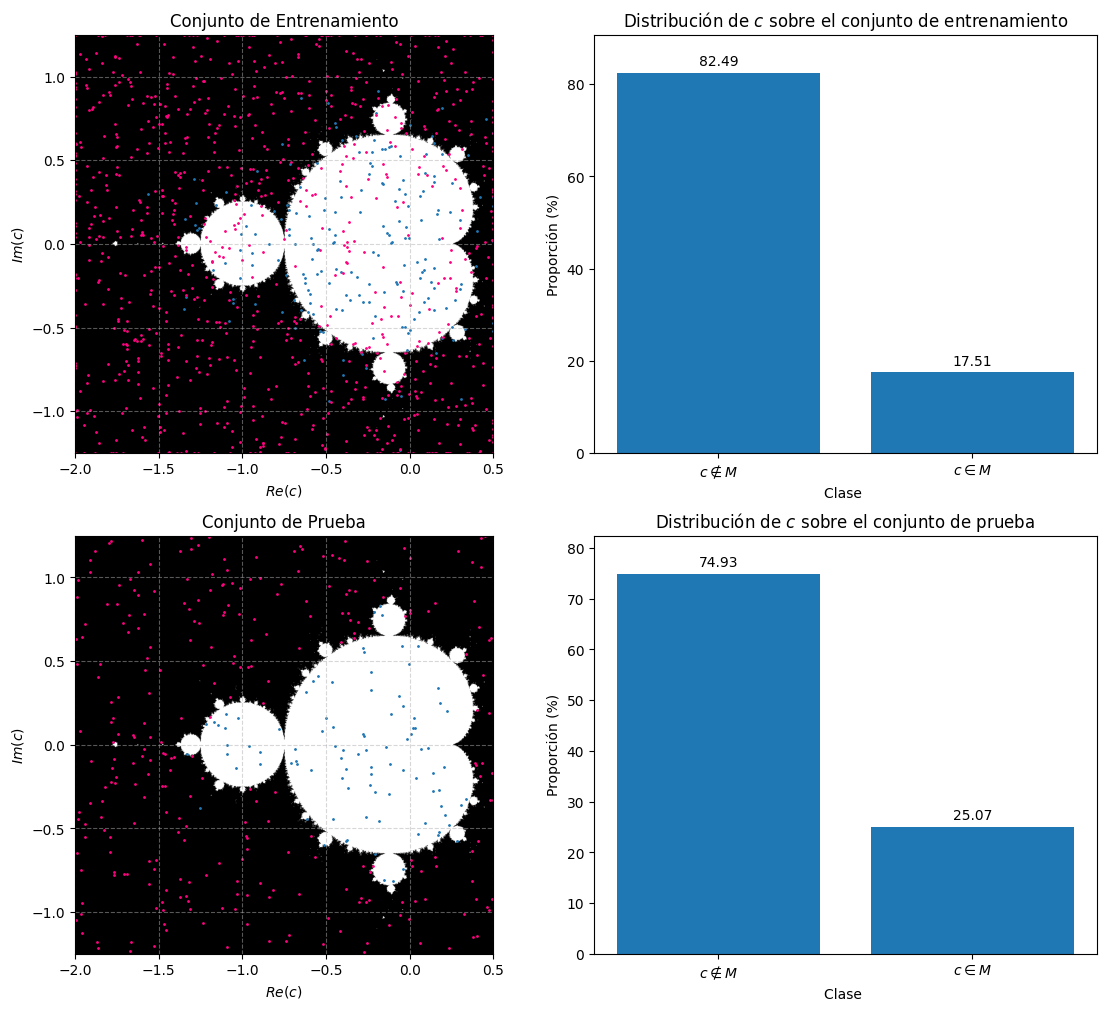

In [12]:
_, class_counts_train = np.unique(y_train, return_counts=True)
class_proportions_train = np.round(class_counts_train/np.sum(class_counts_train) * 100, 2)

_, class_counts_test = np.unique(y_test, return_counts=True)
class_proportions_test = np.round(class_counts_test/np.sum(class_counts_test) * 100, 2)

fig, ax = plt.subplots(2, 2, layout='constrained', figsize=(11, 5*2))

ax[0,0].imshow(mask, extent=(Re_range[0], Re_range[1], Im_range[0], Im_range[1]), origin='lower', cmap='bone')
ax[0,0].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Conjunto de Entrenamiento')
ax[0,0].grid(linestyle='--', alpha=0.5)
ax[0,0].scatter(x_train[y_train, 0], x_train[y_train, 1], s=1, label=r'$c \in M$')
ax[0,0].scatter(x_train[~y_train, 0], x_train[~y_train, 1], s=1, c='#FF007F', label=r'$c \notin M$')

train_bars = ax[0, 1].bar(class_names, class_proportions_train)
ax[0, 1].bar_label(train_bars, padding=3)
ax[0, 1].set(xlabel = 'Clase ', ylabel = 'Proporción (%)', title = 'Distribución de $c$ sobre el conjunto de entrenamiento', ylim=(0, max(class_proportions_train*1.1)))


ax[1,0].imshow(mask, extent=(Re_range[0], Re_range[1], Im_range[0], Im_range[1]), origin='lower', cmap='bone')
ax[1,0].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Conjunto de Prueba')
ax[1,0].grid(linestyle='--', alpha=0.5)
ax[1,0].scatter(x_test[y_test, 0], x_test[y_test, 1], s=1, label=r'$c \in M$')
ax[1,0].scatter(x_test[~y_test, 0], x_test[~y_test, 1], s=1, c='#FF007F', label=r'$c \notin M$')

test_bars = ax[1, 1].bar(class_names, class_proportions_test)
ax[1, 1].bar_label(test_bars, padding=3)
ax[1, 1].set(xlabel = 'Clase ', ylabel = 'Proporción (%)', title = 'Distribución de $c$ sobre el conjunto de prueba', ylim=(0, max(class_proportions_test*1.1)))

plt.show()

Al inspeccionar las distribuciones, se observa que el ruido introducido en el conjunto de entrenamiento incrementó el desbalance de clases, reduciendo la proporción de puntos pertenecientes al conjunto de Mandelbrot. No obstante, el conjunto de prueba conserva las proporciones originales.

## 5. Construcción y Evaulación de los pipelines.

 Dado que el conjunto de Mandelbrot tan solo contiene variables numéricas y que se aplicará el mismo preprocesamiento a cada variable (`StandardScaler()`), no resulta necesario utilizar `ColumnTransformer()`. En su lugar `Pipeline()` se encargará de aplicar el preprocesamiento a cada variable.

In [13]:
preprocessor = StandardScaler()

### 5.1. Árbol de decisión

En esta sección se utiliza el preprocesador definido para crear un pipeline para entrenar un Árbol de Decisión.

In [14]:
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
    ]
)

#### 5.1.1. Entrenamiento del modelo de Árbol de Decisión con búsqueda de hiperparámetros



Para la optimización de hiperparámetros se empleará `RandomizedSearchCV()`. A diferencia de `GridSearchCV()`, este método no realiza una búsqueda exhaustiva, sino que evalúa un subconjunto aleatorio de combinaciones. Aunque no garantiza hallar el óptimo global, permite explorar un espacio de parámetros más amplio con un costo computacional significativamente menor, definido por un número de iteraciones preestablecido. Esta eficiencia facilita la inclusión de múltiples hiperparámetros relevantes sin requerir tiempos de ejecución excesivos.

Para esta exploración, se mantienen los hiperparámetros de la práctica previa pero ampliando sus rangos numéricos. Una adición clave es `class_weight`, que controla la ponderación de las clases durante el entrenamiento. Mientras que el valor por defecto (`None`) otorga un peso equitativo, la opción `balanced` asigna pesos inversamente proporcionales a la frecuencia de las clases, mitigando así el sesgo hacia la clase mayoritaria.

In [15]:
tree_param_distribution = {
        # Hiperparáemtros de la función de costo
        'model__class_weight': ['balanced',   None],

        # Hiperparámetros del criterio de partición
        'model__criterion': ['gini', 'entropy', 'log_loss'],
        'model__splitter': ['best', 'random'],
        'model__max_features': ['sqrt', 'log2', None],

        # Hiperparámetros de complejidad del árbol
        'model__max_depth': [2, 4, 8, 16, 32, 64, 128, 256, 512, None],
        'model__max_leaf_nodes': [2, 4, 8, 16, 32, 64, 128, 256, 512, None]
    }


Se específican los parámetros para la cross validación.

In [16]:
tree_kfold = KFold(n_splits=10, shuffle=True, random_state=42)

La métrica a optimizar será el `F1-Score` en su versión `macro`, es decir, dando igual importancia a todas las clases, con el fin de evitar el sesgo hacia la clase mayoritaria.

In [17]:
decision_tree_random = RandomizedSearchCV(estimator=decision_tree_pipeline, n_iter=100, param_distributions=tree_param_distribution, cv=tree_kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

In [18]:
decision_tree_random.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', None], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [2, 4, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

Una vez finalizado el entrenamiento, se genera un reporte con el desempeño de cada combinación de hiperparámetros evaluada mediante validación cruzada. Al ordenar estos resultados según el `test_score`, es posible identificar qué hiperparámetros tienen el mayor impacto en el rendimiento del modelo.

In [19]:
tree_results = pd.DataFrame(decision_tree_random.cv_results_)
cols = [
    'param_model__class_weight',
    'param_model__criterion',
    'param_model__splitter',
    'param_model__max_features',
    'param_model__max_depth',
    'param_model__max_leaf_nodes',
    'mean_test_score',
    'rank_test_score'
]
summary = tree_results[cols].sort_values(by='rank_test_score')
display(summary)

,param_model__class_weight,param_model__criterion,param_model__splitter,param_model__max_features,param_model__max_depth,param_model__max_leaf_nodes,mean_test_score,rank_test_score
86,NaN,log_loss,best,NaN,512,8,0.728996,1
16,NaN,log_loss,random,NaN,8,128,0.723604,2
39,NaN,gini,best,NaN,4,32,0.723170,3
79,NaN,entropy,random,NaN,256,64,0.706785,4
2,balanced,gini,best,sqrt,16,512,0.703135,5
...,...,...,...,...,...,...,...,...
88,NaN,log_loss,best,log2,4,2,0.451858,88
0,NaN,entropy,best,sqrt,None,2,0.451858,88
85,balanced,log_loss,best,NaN,None,2,0.435108,98
55,balanced,entropy,best,log2,256,2,0.366885,99


#### 5.1.2. Evaluación del mejor Árbol de Decisión

Ahora se utilizará el mejor modelo encontrado durante el proceso de `RandomizedSearch`, para aplicar el pipeline completo al conjunto de prueba para evaluar su desempeño.

In [20]:
best_tree = decision_tree_random.best_estimator_

In [21]:
y_pred_best_tree = best_tree.predict(x_test)
print(classification_report(y_test, y_pred_best_tree))

              precision    recall  f1-score   support

       False       0.90      0.99      0.94       281
        True       0.94      0.67      0.78        94

    accuracy                           0.91       375
   macro avg       0.92      0.83      0.86       375
weighted avg       0.91      0.91      0.90       375



El rendimiento alcanzado es bastante bueno, especialmente dada la complejidad del conjunto de Mandelbrot. No obstante, hay que recordar que estos resultados no se refieren al conjunto fractal puro, sino a una aproximación discretizada y simplificada del mismo.

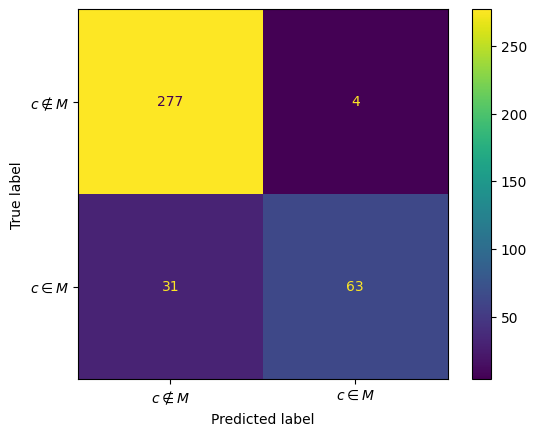

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_tree, display_labels=class_names)
plt.show()

En cuanto a la matriz de confución, se identifica que presenta una mayor cantidad de Falsos Negativo que Falsos Positivo. Por lo que el modelo subestima las fronteras del conjunto de Mandelbrot.

Adicionalmente, la naturaleza bidimensional del conjunto de datos facilita la visualización de las fronteras de decisión. Esto permite inspeccionar gráficamente la lógica del modelo y comprender cómo clasifica las distintas regiones del espacio de características.

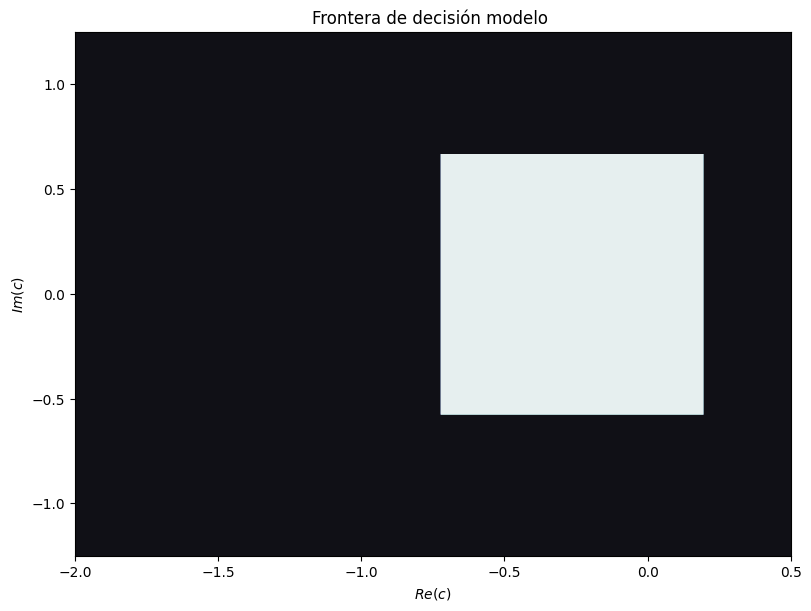

In [23]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

DecisionBoundaryDisplay.from_estimator(
        best_tree,
        x_test,
        cmap=plt.cm.bone,
        response_method="predict",
        ax=ax,
        grid_resolution=1000,
        xlabel='$Re(c)$',
        ylabel='$Im(c)$',
    )
ax.set_xlim(*Re_range)
ax.set_ylim(*Im_range)
ax.set(title='Frontera de decisión modelo ')
plt.show()

Aunque las métricas de clasificación sugieren un ajuste preciso, las fronteras de decisión demuestran que el árbol no ha logrado replicar la morfología fractal del conjunto. Esta discrepancia evidencia una limitación común en los modelos predictivos: la capacidad de obtener resultados estadísticamente satisfactorios mediante simplificaciones que ignoran la verdadera complejidad geométrica del espacio de características.

### 5.2. Bosque Aleatorio

Aunque un solo árbol de decisión logra aproximar las características generales del conjunto de Mandelbrot, presenta dificultades con los detalles finos. Por lo tanto, resulta intuitivo tratar de utilizar múltiples árboles para si el resultado mejora. Esta técnica se conoce como Bosques Aleatorios (Random Forest). En este modelo, el término 'bosque' alude al uso de un conjunto de árboles, mientras que 'aleatorio' indica que cada uno se entrena con ligeras variaciones. Esto permite que los árboles capturen diferentes matices del espacio de características, logrando una capacidad de generalización superior a la de un solo árbol o a un grupo de árboles idénticos.

Para evaluar el desempeño de este modelo, se construye un nuevo pipeline integrándolo como la cabeza de clasificación.

In [24]:
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
    ]
)

#### 5.2.1. Entrenamiento del modelo de Bosque Aleatorio con búsqueda de hiperparámetros



Para entrenar los Bosques Aleatorios se replica el procedimiento utilizado para un árbol de decisión, añadiendo dos hiperparámetros: `n_estimators`, para establecer el número de árboles, y `bootstrap`. Este último indica si el entrenamiento se realiza mediante muestreo aleatorio (con reemplazo) o utilizando la totalidad del conjunto de datos.

In [25]:
forest_param_distribution = {
        # Hiperparámetros de ensamble
        'model__n_estimators': [2, 4, 8, 16, 32, 64],
        'model__bootstrap': [True, False],

        # Hiperparáemtros de la función de costo
        'model__class_weight': ['balanced',   None],

        # Hiperparámetros del criterio de partición
        'model__criterion': ['gini', 'entropy', 'log_loss'],
        'model__max_features': ['sqrt', 'log2', None],

        # Hiperparámetros de complejidad del árbol
        'model__max_depth': [2, 4, 8, 16, 32, 64, 128, 256, 512, None],
        'model__max_leaf_nodes': [2, 4, 8, 16, 32, 64, 128, 256, 512, None]
    }

In [26]:
forest_kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [27]:
random_forest_random = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    n_iter=100,
    param_distributions=forest_param_distribution,
    cv=forest_kfold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1)

In [28]:
random_forest_random.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__class_weight': ['balanced', None], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [29]:
forest_results = pd.DataFrame(random_forest_random.cv_results_)
cols = [

    'param_model__n_estimators',
    'param_model__bootstrap',
    'param_model__class_weight',
    'param_model__criterion',
    'param_model__max_features',
    'param_model__max_depth',
    'param_model__max_leaf_nodes',
    'param_model__class_weight',
    'mean_test_score',
    'rank_test_score'
]
summary = forest_results[cols].sort_values(by='rank_test_score')
display(summary)

,param_model__n_estimators,param_model__bootstrap,param_model__class_weight,param_model__criterion,param_model__max_features,param_model__max_depth,param_model__max_leaf_nodes,param_model__class_weight,mean_test_score,rank_test_score
22,32,True,balanced,log_loss,NaN,16,256,balanced,0.741821,1
60,64,True,balanced,gini,log2,16,256,balanced,0.741661,2
88,32,True,NaN,log_loss,NaN,32,32,NaN,0.737994,3
41,64,True,NaN,entropy,log2,256,128,NaN,0.736204,4
83,32,True,balanced,gini,sqrt,64,32,balanced,0.734984,5
...,...,...,...,...,...,...,...,...,...,...
75,32,True,NaN,log_loss,NaN,64,2,NaN,0.451858,90
9,8,True,NaN,gini,NaN,4,2,NaN,0.451858,90
63,16,True,NaN,gini,NaN,256,2,NaN,0.451858,90
15,32,True,NaN,gini,sqrt,2,4,NaN,0.451858,90


#### 5.2.2. Evaluación del mejor Bosque Aleatorio

In [30]:
best_forest = random_forest_random.best_estimator_

In [31]:
y_pred_best_forest = best_forest.predict(x_test)
print(classification_report(y_test, y_pred_best_forest, zero_division=1))

              precision    recall  f1-score   support

       False       0.86      0.98      0.91       281
        True       0.88      0.53      0.66        94

    accuracy                           0.86       375
   macro avg       0.87      0.75      0.79       375
weighted avg       0.87      0.86      0.85       375



En cuanto al desempeño del modelo se observa que este aumenta ligeramente.

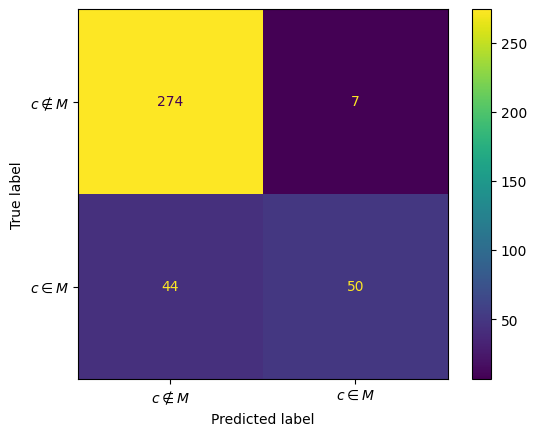

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_forest, display_labels=class_names)
plt.show()

En particular, se presenta un número similar de Falsos Positivos y Falsos Negativos.

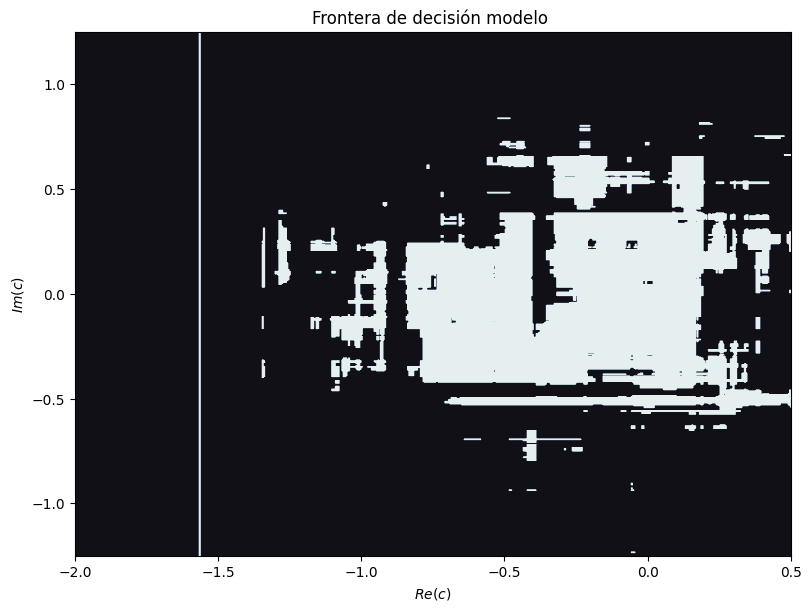

In [33]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

DecisionBoundaryDisplay.from_estimator(
        best_forest,
        x_test,
        cmap=plt.cm.bone,
        response_method="predict",
        ax=ax,
        grid_resolution=1000,
        xlabel='$Re(c)$',
        ylabel='$Im(c)$',
    )
ax.set_xlim(*Re_range)
ax.set_ylim(*Im_range)
ax.set(title='Frontera de decisión modelo ')
plt.show()

No obstante, la diferencia más significativa se observa en la frontera de decisión. Mientras que el modelo anterior generaba divisiones gruesas y simples, el uso de múltiples árboles permite que la combinación de sus fronteras resulte en una región mucho más refinada. Esta estructura es capaz de capturar detalles y patrones complejos que un solo árbol de decisión ignoraría.

### 5.3. KNN (K-Nearest Neighbors)

Con el objetivo de explorar un clasificador distinto a los anteriores, se presenta K-Nearest Neighbors (KNN): un clasificador basado en distancias, notablemente sencillo pero altamente efectivo. A diferencia de otros modelos, KNN no aprende un conjunto de parámetros durante el entrenamiento. En su lugar, utiliza los datos almacenados durante la fase de predicción para identificar los $k$ vecinos más cercanos a cada punto. Finalmente, asigna la clase mayoritaria entre dichos vecinos, siendo $k$ el hiperparámetro principal del modelo.

In [34]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
    ]
)

#### 5.3.1. Entrenamiento del modelo de KNN con búsqueda de hiperparámetros



El entrenamiento de KNN sigue el flujo de trabajo establecido, diferenciándose principalmente en la configuración de la distribución de hiperparámetros para la validación cruzada. Entre estos destacan: `n_neighbors` $(k)$, cuyo valor suele oscilar entre 1 y 5 para distribuciones con cambios abruptos, o entre 20 y 50 para mitigar el ruido. El parámetro `weights` define si la influencia de los vecinos es equitativa o proporcional a su distancia, mientras que `algorithm` y `leaf_size` optimizan la búsqueda espacial mediante estructuras de datos. Finalmente, `p` y `metric` determinan la métrica de distancia, permitiendo alternar entre normas como $L_1$ (Manhattan), $L_2$ (Euclidiana) o la diferencia máxima (Chebyshev).

In [35]:
knn_param_distribution = {

        'model__n_neighbors': [1, 2, 3, 4, 5, 20, 25, 30, 35, 40, 45, 50],
        'model__weights': ['uniform', 'distance'],
        'model__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'model__leaf_size': [20, 25, 30, 35, 40],
        'model__p': [1, 2],
        'model__metric': ['minkowski', 'chebyshev']
    }

In [36]:
knn_kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [37]:
knn_random = RandomizedSearchCV(
    estimator=knn_pipeline,
    n_iter=100,
    param_distributions=knn_param_distribution,
    cv=knn_kfold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1)

In [38]:
knn_random.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__algorithm': ['ball_tree', 'kd_tree', ...], 'model__leaf_size': [20, 25, ...], 'model__metric': ['minkowski', 'chebyshev'], 'model__n_neighbors': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

In [39]:
knn_results = pd.DataFrame(knn_random.cv_results_)
cols = [

    'param_model__n_neighbors',
    'param_model__weights',
    'param_model__algorithm',
    'param_model__leaf_size',
    'param_model__p',
    'param_model__metric',
    'mean_test_score',
    'rank_test_score'
]
summary = knn_results[cols].sort_values(by='rank_test_score')
display(summary)

,param_model__n_neighbors,param_model__weights,param_model__algorithm,param_model__leaf_size,param_model__p,param_model__metric,mean_test_score,rank_test_score
4,5,uniform,kd_tree,30,1,minkowski,0.741320,1
20,5,uniform,ball_tree,25,1,minkowski,0.741320,1
82,40,distance,brute,25,1,minkowski,0.740604,3
81,40,distance,kd_tree,20,1,minkowski,0.740604,3
69,35,distance,brute,30,2,minkowski,0.740477,5
...,...,...,...,...,...,...,...,...
26,4,uniform,brute,35,1,minkowski,0.676333,96
59,4,uniform,brute,25,1,minkowski,0.676333,96
63,2,uniform,kd_tree,35,1,chebyshev,0.669033,98
3,2,uniform,ball_tree,25,2,chebyshev,0.666336,99


#### 5.3.2. Evaluación del mejor KNN

In [40]:
best_knn = knn_random.best_estimator_

In [41]:
y_pred_best_knn = best_knn.predict(x_test)
print(classification_report(y_test, y_pred_best_knn, zero_division=1))

              precision    recall  f1-score   support

       False       0.87      0.99      0.93       281
        True       0.95      0.57      0.72        94

    accuracy                           0.89       375
   macro avg       0.91      0.78      0.82       375
weighted avg       0.89      0.89      0.87       375



En este caso, el rendimiento de este modelo se ve altamente afectado por el nivel de ruido introducido.

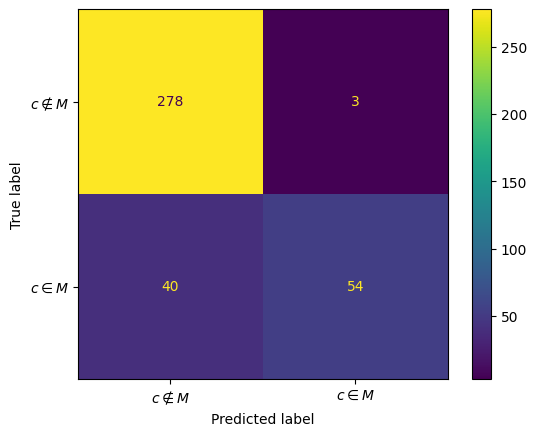

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_knn, display_labels=class_names)
plt.show()

Aspecto que se puede observar en el elevado número de Falsos negativos.

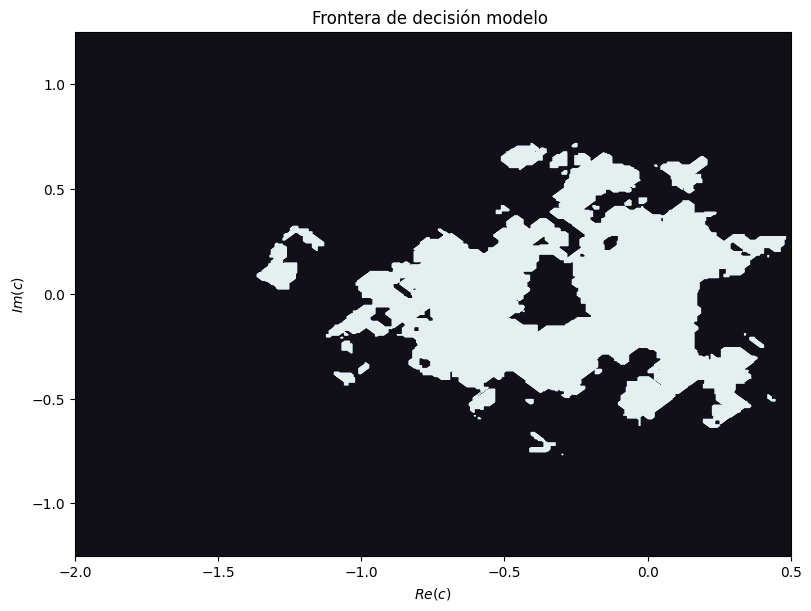

In [43]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

DecisionBoundaryDisplay.from_estimator(
        best_knn,
        x_test,
        cmap=plt.cm.bone,
        response_method="predict",
        ax=ax,
        grid_resolution=1000,
        xlabel='$Re(c)$',
        ylabel='$Im(c)$',
    )
ax.set_xlim(*Re_range)
ax.set_ylim(*Im_range)
ax.set(title='Frontera de decisión modelo ')
plt.show()

Y en la frontera de decisión resultante, la cual no logra ser convexa por el ruido introducido.

### 5.4. SMOTE [(Synthetic Minority Over-sampling Technique)](https://arxiv.org/abs/1106.1813)

Para mitigar el impacto del ruido y el desbalance de clases, se utiliza la técnica SMOTE. A diferencia del sobremuestreo tradicional, SMOTE no duplica registros existentes, sino que genera instancias sintéticas mediante la interpolación lineal entre ejemplos de la clase minoritaria y sus vecinos más cercanos. Esto permite enriquecer el conjunto de datos con ejemplos nuevos y plausibles, mejorando la capacidad de generalización del modelo.

El efecto de esta técnica se evaluará mediante dos clasificadores: Random Forest y KNN. Para ello, se implementarán dos nuevos pipelines utilizando la librería `imblearn`, los cuales integran un remuestreo con SMOTE previo al entrenamiento. Esta estructura garantiza que el balanceo de clases se realice correctamente dentro de la validación cruzada.

In [44]:
random_forest_smote_pipeline = ImbPipeline(steps=[
      ('preprocessor', preprocessor),
      ('smote', SMOTE(random_state=42)),
      ('model', RandomForestClassifier())
      ]
  )

In [45]:
knn_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier())
    ]
)

##### 5.4.1. Entrenamiento del modelo de Bosque Aleatorio con SMOTE y búsqueda de hiperparámetros



La implementación de SMOTE introduce dos hiperparámetros clave: `sampling_strategy` que define la proporción deseada de la clase minoritaria tras el remuestreo, y `k_neighbors`, que establece el número de vecinos cercanos considerados para generar las interpolaciones sintéticas.

In [46]:
forest_smote_param_distribution = {
        # Hiperparámetros de SMOTE
        'smote__sampling_strategy': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 'auto'],
        'smote__k_neighbors': [1, 2, 3, 4, 5, 20, 25, 30, 35, 40, 45, 50],

        # Hiperparámetros de ensamble
        'model__n_estimators': [2, 4, 8, 16, 32, 64],
        'model__bootstrap': [True, False],

        # Hiperparáemtros de la función de costo
        'model__class_weight': ['balanced',   None],

        # Hiperparámetros del criterio de partición
        'model__criterion': ['gini', 'entropy', 'log_loss'],
        'model__max_features': ['sqrt', 'log2', None],

        # Hiperparámetros de complejidad del árbol
        'model__max_depth': [2, 4, 8, 16, 32, 64, 128, 256, 512, None],
        'model__max_leaf_nodes': [2, 4, 8, 16, 32, 64, 128, 256, 512, None]
    }

In [47]:
random_forest_smote_random = RandomizedSearchCV(
    estimator=random_forest_smote_pipeline,
    n_iter=100,
    param_distributions=forest_smote_param_distribution,
    cv=forest_kfold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1)

In [48]:
random_forest_smote_random.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__class_weight': ['balanced', None], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [49]:
smote_forest_results = pd.DataFrame(random_forest_smote_random.cv_results_)
cols = [
    'param_smote__sampling_strategy',
    'param_smote__k_neighbors',
    'param_model__n_estimators',
    'param_model__bootstrap',
    'param_model__class_weight',
    'param_model__criterion',
    'param_model__max_features',
    'param_model__max_depth',
    'param_model__max_leaf_nodes',
    'param_model__class_weight',
    'mean_test_score',
    'rank_test_score'
]
summary = smote_forest_results[cols].sort_values(by='rank_test_score')
display(summary)

,param_smote__sampling_strategy,param_smote__k_neighbors,param_model__n_estimators,param_model__bootstrap,param_model__class_weight,param_model__criterion,param_model__max_features,param_model__max_depth,param_model__max_leaf_nodes,param_model__class_weight,mean_test_score,rank_test_score
35,0.4,1,32,True,balanced,log_loss,log2,32,128,balanced,0.742051,1
75,0.6,40,16,True,balanced,log_loss,log2,None,512,balanced,0.739354,2
91,0.8,25,8,True,NaN,log_loss,log2,16,256,NaN,0.739098,3
9,0.9,50,16,True,balanced,gini,log2,512,128,balanced,0.735745,4
61,0.5,2,64,True,NaN,entropy,log2,8,16,NaN,0.735157,5
...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.5,40,2,False,balanced,gini,sqrt,None,2,balanced,0.538427,96
64,0.9,30,64,True,NaN,gini,NaN,256,2,NaN,0.516646,97
59,0.6,3,4,False,balanced,log_loss,log2,4,2,balanced,0.491890,98
12,0.5,5,16,True,NaN,gini,log2,128,2,NaN,0.451858,99


#### 5.4.2. Evaluación del mejor Bosque Aleatorio con SMOTE

In [50]:
best_forest_smote = random_forest_smote_random.best_estimator_

In [51]:
y_pred_best_forest_smote = best_forest_smote.predict(x_test)
print(classification_report(y_test, y_pred_best_forest_smote, zero_division=1))

              precision    recall  f1-score   support

       False       0.90      0.98      0.93       281
        True       0.90      0.66      0.76        94

    accuracy                           0.90       375
   macro avg       0.90      0.82      0.85       375
weighted avg       0.90      0.90      0.89       375



Se evidencia que la inclusión de SMOTE mejora el desempeño del modelo.

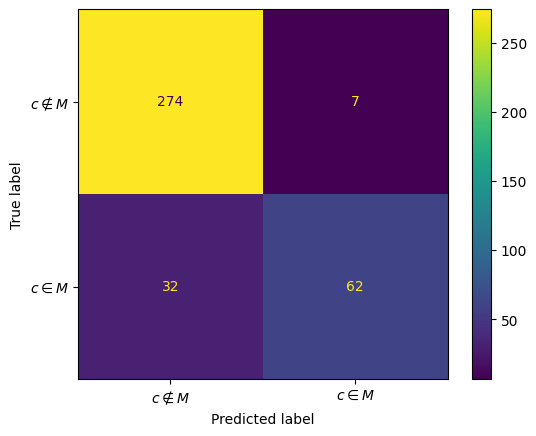

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_forest_smote, display_labels=class_names)
plt.show()

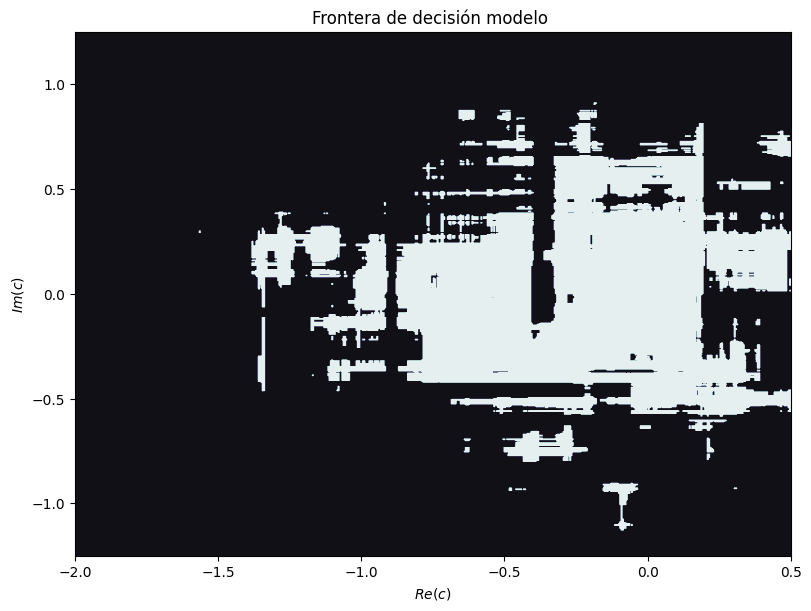

In [53]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

DecisionBoundaryDisplay.from_estimator(
        best_forest_smote,
        x_test,
        cmap=plt.cm.bone,
        response_method="predict",
        ax=ax,
        grid_resolution=1000,
        xlabel='$Re(c)$',
        ylabel='$Im(c)$',
    )
ax.set_xlim(*Re_range)
ax.set_ylim(*Im_range)
ax.set(title='Frontera de decisión modelo ')
plt.show()

En particular, el análisis de la frontera de decisión revela que el impacto de SMOTE consistió principalmente en la clausura de la región de la clase minoritaria. Esto permitió cerrar huecos en la frontera, generando una superficie más continua y compacta que captura mejor la estructura del conjunto.

#### 5.4.3. Entrenamiento del modelo KNN con SMOTE y búsqueda de hiperparámetros

In [54]:
knn_smote_param_distribution = {
        # Hiperparámetros de SMOTE
        'smote__sampling_strategy': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 'auto'],
        'smote__k_neighbors': [1, 2, 3, 4, 5, 20, 25, 30, 35, 40, 45, 50],

        'model__n_neighbors': [1, 2, 3, 4, 5, 20, 25, 30, 35, 40, 45, 50],
        'model__weights': ['uniform', 'distance'],
        'model__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'model__leaf_size': [20, 25, 30, 35, 40],
        'model__p': [1, 2],
        'model__metric': ['minkowski', 'chebyshev']
    }

In [55]:
knn_smote_random = RandomizedSearchCV(
    estimator=knn_smote_pipeline,
    n_iter=100,
    param_distributions=knn_smote_param_distribution,
    cv=knn_kfold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1)

In [56]:
knn_smote_random.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__algorithm': ['ball_tree', 'kd_tree', ...], 'model__leaf_size': [20, 25, ...], 'model__metric': ['minkowski', 'chebyshev'], 'model__n_neighbors': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

In [57]:
knn_smote_results = pd.DataFrame(knn_smote_random.cv_results_)
cols = [
    'param_smote__sampling_strategy',
    'param_smote__k_neighbors',
    'param_model__n_neighbors',
    'param_model__weights',
    'param_model__algorithm',
    'param_model__leaf_size',
    'param_model__p',
    'param_model__metric',
    'mean_test_score',
    'rank_test_score'
]
summary = knn_smote_results[cols].sort_values(by='rank_test_score')
display(summary)

,param_smote__sampling_strategy,param_smote__k_neighbors,param_model__n_neighbors,param_model__weights,param_model__algorithm,param_model__leaf_size,param_model__p,param_model__metric,mean_test_score,rank_test_score
7,0.4,40,50,distance,brute,20,2,chebyshev,0.764678,1
35,0.5,3,25,distance,brute,25,1,minkowski,0.760063,2
41,0.4,35,50,uniform,brute,35,1,chebyshev,0.756318,3
32,0.4,4,30,distance,ball_tree,20,2,minkowski,0.754867,4
75,0.5,40,5,uniform,brute,40,1,minkowski,0.749456,5
...,...,...,...,...,...,...,...,...,...,...
1,0.4,5,1,uniform,brute,25,2,chebyshev,0.692401,96
81,auto,1,30,uniform,kd_tree,25,1,chebyshev,0.688880,97
62,auto,4,50,uniform,ball_tree,30,2,minkowski,0.688596,98
20,0.6,1,2,distance,brute,25,2,chebyshev,0.685959,99


#### 5.4.4. Evaluación del mejor KNN con SMOTE

In [58]:
best_knn_smote = knn_smote_random.best_estimator_

In [59]:
y_pred_best_knn_smote = best_knn_smote.predict(x_test)
print(classification_report(y_test, y_pred_best_knn_smote, zero_division=1))

              precision    recall  f1-score   support

       False       0.91      0.98      0.94       281
        True       0.91      0.72      0.80        94

    accuracy                           0.91       375
   macro avg       0.91      0.85      0.87       375
weighted avg       0.91      0.91      0.91       375



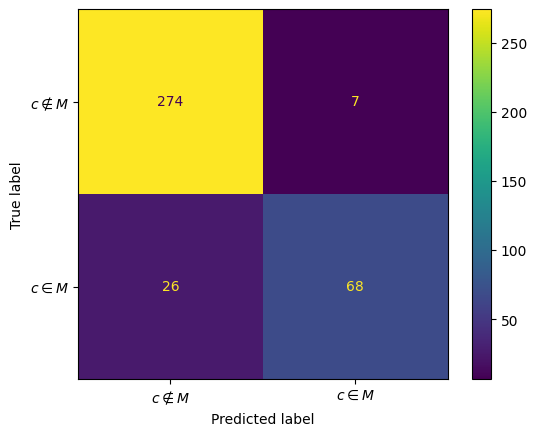

In [60]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_knn_smote, display_labels=class_names)
plt.show()

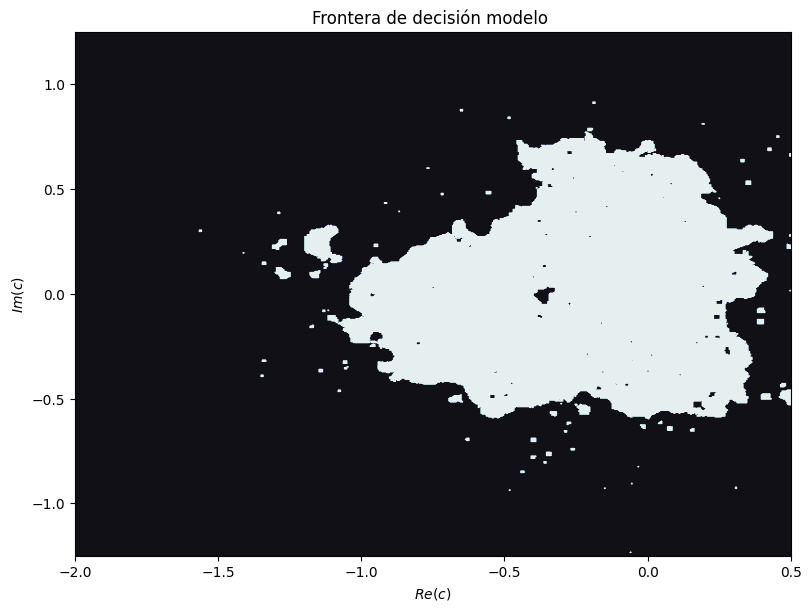

In [61]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

DecisionBoundaryDisplay.from_estimator(
        best_knn_smote,
        x_test,
        cmap=plt.cm.bone,
        response_method="predict",
        ax=ax,
        grid_resolution=1000,
        xlabel='$Re(c)$',
        ylabel='$Im(c)$',
    )
ax.set_xlim(*Re_range)
ax.set_ylim(*Im_range)
ax.set(title='Frontera de decisión modelo ')
plt.show()

El sobremuestreo de la clase minoritaria, le permite al modelo de KNN determinar gran precisión la estructura subyaciente del conjunto de mandelbrot, capturando parcialmente la complejidad de las fronteras y cerrando el conjunto en sus interiores.

## 6. Persistencia del pipeline entrenado.

Se persiste el último modelo.

In [62]:
joblib.dump(best_knn_smote, 'knn_smote.joblib')

['knn_smote.joblib']

## 7. Ejercicios

+ **Ejercicio 1**. En la Sección 4 (Partición de los datos), se modificaron las etiquetas del 25% de los puntos pertenecientes al interior del conjunto de Mandelbrot. ¿Qué efectos se observarían si, por el contrario, se alterara el 25% de las etiquetas de los puntos externos al conjunto? Responda cómo afectaría esto a cada modelo antes de ejecutar el reentrenamiento. Tras implementar el cambio, valide si el comportamiento observado se ajusta a lo esperado.


+ **Ejercicio 2**. En la Sección 4 también se define el número de puntos destinado a los conjuntos de entrenamiento y prueba. ¿Qué efectos tendría mantener la proporción de la partición, pero incrementar el número total de puntos? Analice cómo este aumento impactaría en las métricas de desempeño y las fronteras de decisión de los modelos. Plantee una hipótesis para cada modelo y, tras realizar el experimento, verifique si los resultados confirman sus suposiciones.


+ **Ejercicio 3**. Finalmente, se introdujo una cantidad sustancial de ruido en el conjunto de entrenamiento original. ¿Qué sucedería si este ruido se eliminara por completo? Analice cómo se verían afectados el desempeño y las fronteras de decisión de los modelos en un escenario ideal. Asimismo, si se reentrena sobre un conjunto libre de ruido, ¿cuál sería el impacto de variar el número de puntos en el entrenamiento?"

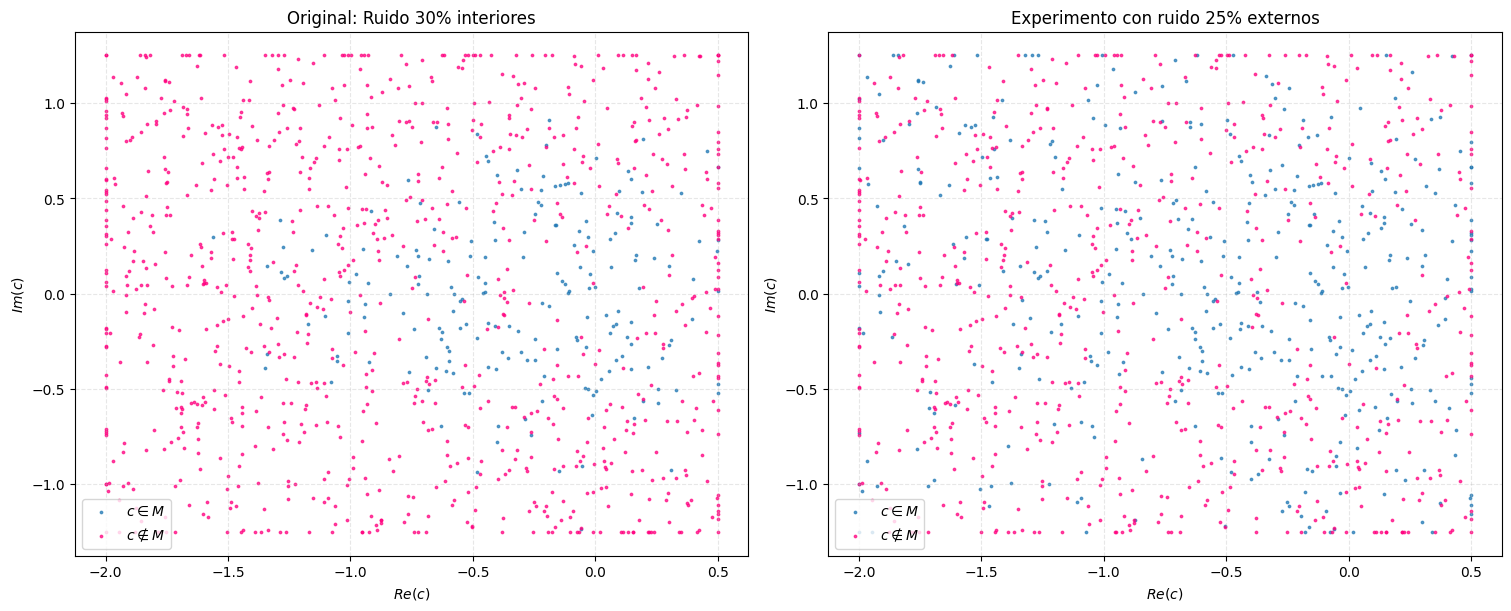

Puntos externos con etiquetas alteradas: 232/928


In [63]:
x_train_original = x_train.copy()
y_train_original = y_train.copy()

outside_points_indices = np.argwhere(~y_train)

noise_probability_ext = 0.25
num_noisy_points_ext = int(len(outside_points_indices)*noise_probability_ext)

noisy_points_indices_ext = np.random.choice(
    len(outside_points_indices), 
    size=num_noisy_points_ext, 
    replace=False
)

y_train_ext_noise = y_train.copy()
y_train_ext_noise[outside_points_indices[noisy_points_indices_ext]] = ~y_train_ext_noise[outside_points_indices[noisy_points_indices_ext]]

fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

ax[0].scatter(x_train_original[y_train_original, 0], x_train_original[y_train_original, 1], s=3, label=r'$c \in M$', alpha=0.7)
ax[0].scatter(x_train_original[~y_train_original, 0], x_train_original[~y_train_original, 1], s=3, c='#FF007F', label=r'$c \notin M$', alpha=0.7)
ax[0].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Original: Ruido 30% interiores')
ax[0].legend()
ax[0].grid(linestyle='--', alpha=0.3)
ax[1].scatter(x_train_original[y_train_ext_noise, 0], x_train_original[y_train_ext_noise, 1], s=3, label=r'$c \in M$', alpha=0.7)
ax[1].scatter(x_train_original[~y_train_ext_noise, 0], x_train_original[~y_train_ext_noise, 1], s=3, c='#FF007F', label=r'$c \notin M$', alpha=0.7)
ax[1].set(xlabel='$Re(c)$', ylabel='$Im(c)$', title='Experimento con ruido 25% externos')
ax[1].legend()
ax[1].grid(linestyle='--', alpha=0.3)

plt.show()

print(f"Puntos externos con etiquetas alteradas: {num_noisy_points_ext}/{len(outside_points_indices)}")

In [69]:
# === Métricas base (original) ===
# Usa el set "original" sin ruido de etiquetas extra para tener comparación limpia
tree_orig = decision_tree_pipeline.fit(x_train_original, y_train_original)
forest_orig = random_forest_pipeline.fit(x_train_original, y_train_original)
knn_orig = knn_pipeline.fit(x_train_original, y_train_original)

y_pred_tree_orig = tree_orig.predict(x_test)
y_pred_forest_orig = forest_orig.predict(x_test)
y_pred_knn_orig = knn_orig.predict(x_test)

acc_tree_orig = accuracy_score(y_test, y_pred_tree_orig)
acc_forest_orig = accuracy_score(y_test, y_pred_forest_orig)
acc_knn_orig = accuracy_score(y_test, y_pred_knn_orig)

# === Métricas experimento ruido en externos ===
tree_ext = decision_tree_pipeline.fit(x_train_original, y_train_ext_noise)
forest_ext = random_forest_pipeline.fit(x_train_original, y_train_ext_noise)
knn_ext = knn_pipeline.fit(x_train_original, y_train_ext_noise)

y_pred_tree_ext = tree_ext.predict(x_test)
y_pred_forest_ext = forest_ext.predict(x_test)
y_pred_knn_ext = knn_ext.predict(x_test)

acc_tree_ext = accuracy_score(y_test, y_pred_tree_ext)
acc_forest_ext = accuracy_score(y_test, y_pred_forest_ext)
acc_knn_ext = accuracy_score(y_test, y_pred_knn_ext)

delta_tree = acc_tree_ext - acc_tree_orig
delta_forest = acc_forest_ext - acc_forest_orig
delta_knn = acc_knn_ext - acc_knn_orig

print("Variables creadas:")
print("acc_tree_orig, acc_forest_orig, acc_knn_orig")
print("acc_tree_ext, acc_forest_ext, acc_knn_ext")
print("delta_tree, delta_forest, delta_knn")

Variables creadas:
acc_tree_orig, acc_forest_orig, acc_knn_orig
acc_tree_ext, acc_forest_ext, acc_knn_ext
delta_tree, delta_forest, delta_knn


In [70]:
comparision_results_ex1 = pd.DataFrame({
    'Modelo': ['Árbol Original', 'Random Forest Original', 'KNN Original',
               'Árbol (ruido ext)', 'Random Forest (ruido ext)', 'KNN (ruido ext)'],
    'Accuracy Original': [acc_tree_orig, acc_forest_orig, acc_knn_orig,
                          '---', '---', '---'],
    'Accuracy Ruido Ext': ['---', '---', '---',
                           acc_tree_ext, acc_forest_ext, acc_knn_ext],
    'Impacto': ['', '', '', delta_tree, delta_forest, delta_knn]
})

display(comparision_results_ex1)

,Modelo,Accuracy Original,Accuracy Ruido Ext,Impacto
0,Árbol Original,0.821333,---,
1,Random Forest Original,0.856,---,
2,KNN Original,0.877333,---,
3,Árbol (ruido ext),---,0.704,-0.117333
4,Random Forest (ruido ext),---,0.821333,-0.034667
5,KNN (ruido ext),---,0.797333,-0.08



Experimento con 1500 puntos
Árbol F1-Score: 0.7500
Random Forest F1-Score: 0.8044
KNN F1-Score: 0.7789

Experimento con 3000 puntos
Árbol F1-Score: 0.6719
Random Forest F1-Score: 0.7350
KNN F1-Score: 0.7563

Experimento con 5000 puntos
Árbol F1-Score: 0.7354
Random Forest F1-Score: 0.7601
KNN F1-Score: 0.7593

Experimento con 7500 puntos
Árbol F1-Score: 0.7227
Random Forest F1-Score: 0.7454
KNN F1-Score: 0.7253


,num_points,tree_f1,forest_f1,knn_f1
0,1500,0.750000,0.804386,0.778871
1,3000,0.671892,0.735047,0.756341
2,5000,0.735450,0.760062,0.759303
3,7500,0.722738,0.745352,0.725288


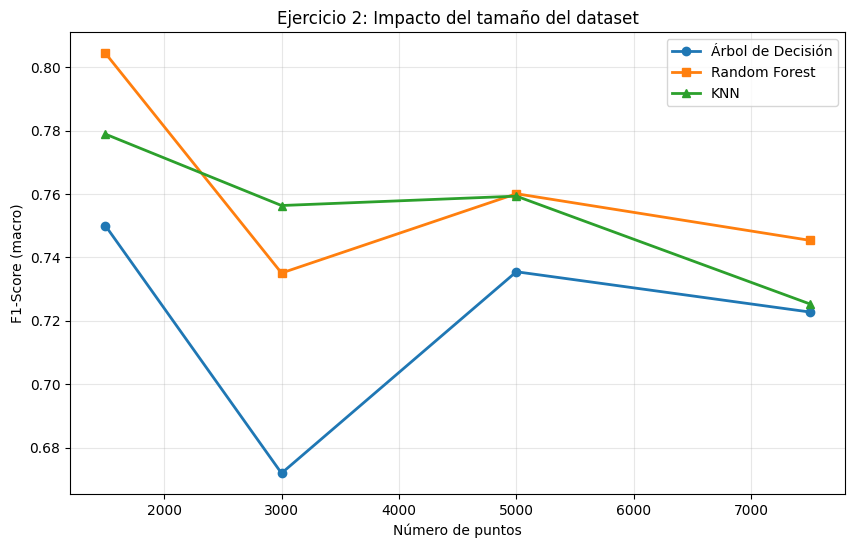

In [71]:
# EJERCICIO 2: Aumentar número de puntos (manteniendo proporción 75-25)

# Probar con 3000, 5000 y 7500 puntos
num_points_list = [1500, 3000, 5000, 7500]
results_ex2 = {
    'num_points': [],
    'tree_f1': [],
    'forest_f1': [],
    'knn_f1': []
}

for num_points_exp in num_points_list:
    print(f"\n{'='*60}")
    print(f"Experimento con {num_points_exp} puntos")
    print(f"{'='*60}")
    
    # Generar nuevos índices
    mask_indices_exp = np.random.choice(total_pixels, size=num_points_exp, replace=False)
    
    rows_exp, cols_exp = np.unravel_index(mask_indices_exp, (h, w))
    x_pixels_exp = np.column_stack((cols_exp, rows_exp))
    
    x_exp = np.zeros_like(x_pixels_exp, dtype=float)
    x_exp[:, 0] = Re_range[0] + (x_pixels_exp[:, 0] / (w - 1)) * (Re_range[1] - Re_range[0])
    x_exp[:, 1] = Im_range[0] + (x_pixels_exp[:, 1] / (h - 1)) * (Im_range[1] - Im_range[0])
    
    y_exp = mask[x_pixels_exp[:, 1], x_pixels_exp[:, 0]]
    
    x_train_exp, x_test_exp, y_train_exp, y_test_exp = \
        train_test_split(x_exp, y_exp, test_size=0.25, stratify=y_exp)
    
    # Agregar ruido
    x_train_exp += np.random.normal(0, 0.25, x_train_exp.shape)
    x_train_exp[:, 0] = np.clip(x_train_exp[:, 0], a_min=Re_range[0], a_max=Re_range[1])
    x_train_exp[:, 1] = np.clip(x_train_exp[:, 1], a_min=Im_range[0], a_max=Im_range[1])
    
    inside_points_indices_exp = np.argwhere(y_train_exp)
    noise_probability = 0.3
    num_noisy_points_exp = int(len(inside_points_indices_exp)*noise_probability)
    noisy_points_indices_exp = np.random.choice(len(inside_points_indices_exp), 
                                               size=num_noisy_points_exp, replace=False)
    y_train_exp[inside_points_indices_exp[noisy_points_indices_exp]] = \
        ~y_train_exp[inside_points_indices_exp[noisy_points_indices_exp]]
    
    # Entrenar 3 modelos
    # Árbol
    tree_exp = decision_tree_pipeline.fit(x_train_exp, y_train_exp)
    y_pred_tree_exp = tree_exp.predict(x_test_exp)
    f1_tree_exp = f1_score(y_test_exp, y_pred_tree_exp, average='macro')
    
    # Random Forest
    forest_exp = random_forest_pipeline.fit(x_train_exp, y_train_exp)
    y_pred_forest_exp = forest_exp.predict(x_test_exp)
    f1_forest_exp = f1_score(y_test_exp, y_pred_forest_exp, average='macro')
    
    # KNN
    knn_exp = knn_pipeline.fit(x_train_exp, y_train_exp)
    y_pred_knn_exp = knn_exp.predict(x_test_exp)
    f1_knn_exp = f1_score(y_test_exp, y_pred_knn_exp, average='macro')
    
    results_ex2['num_points'].append(num_points_exp)
    results_ex2['tree_f1'].append(f1_tree_exp)
    results_ex2['forest_f1'].append(f1_forest_exp)
    results_ex2['knn_f1'].append(f1_knn_exp)
    
    print(f"Árbol F1-Score: {f1_tree_exp:.4f}")
    print(f"Random Forest F1-Score: {f1_forest_exp:.4f}")
    print(f"KNN F1-Score: {f1_knn_exp:.4f}")

# Visualizar cambios
df_results_ex2 = pd.DataFrame(results_ex2)
display(df_results_ex2)

# Gráfica de tendencias
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_results_ex2['num_points'], df_results_ex2['tree_f1'], 
        marker='o', label='Árbol de Decisión', linewidth=2)
ax.plot(df_results_ex2['num_points'], df_results_ex2['forest_f1'], 
        marker='s', label='Random Forest', linewidth=2)
ax.plot(df_results_ex2['num_points'], df_results_ex2['knn_f1'], 
        marker='^', label='KNN', linewidth=2)
ax.set(xlabel='Número de puntos', ylabel='F1-Score (macro)', 
       title='Ejercicio 2: Impacto del tamaño del dataset')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


Entrenando con: Sin ruido (posición limpia)
  Árbol - F1: 0.7301, Acc: 0.8213
  RF    - F1: 0.7685, Acc: 0.8587
  KNN   - F1: 0.8083, Acc: 0.8773

Entrenando con: Sin ruido (posición ruidosa)
  Árbol - F1: 0.7787, Acc: 0.8320
  RF    - F1: 0.8398, Acc: 0.8853
  KNN   - F1: 0.8173, Acc: 0.8667

Entrenando con: Original (ruido etiqueta)
  Árbol - F1: 0.7360, Acc: 0.8293
  RF    - F1: 0.7685, Acc: 0.8587
  KNN   - F1: 0.8083, Acc: 0.8773


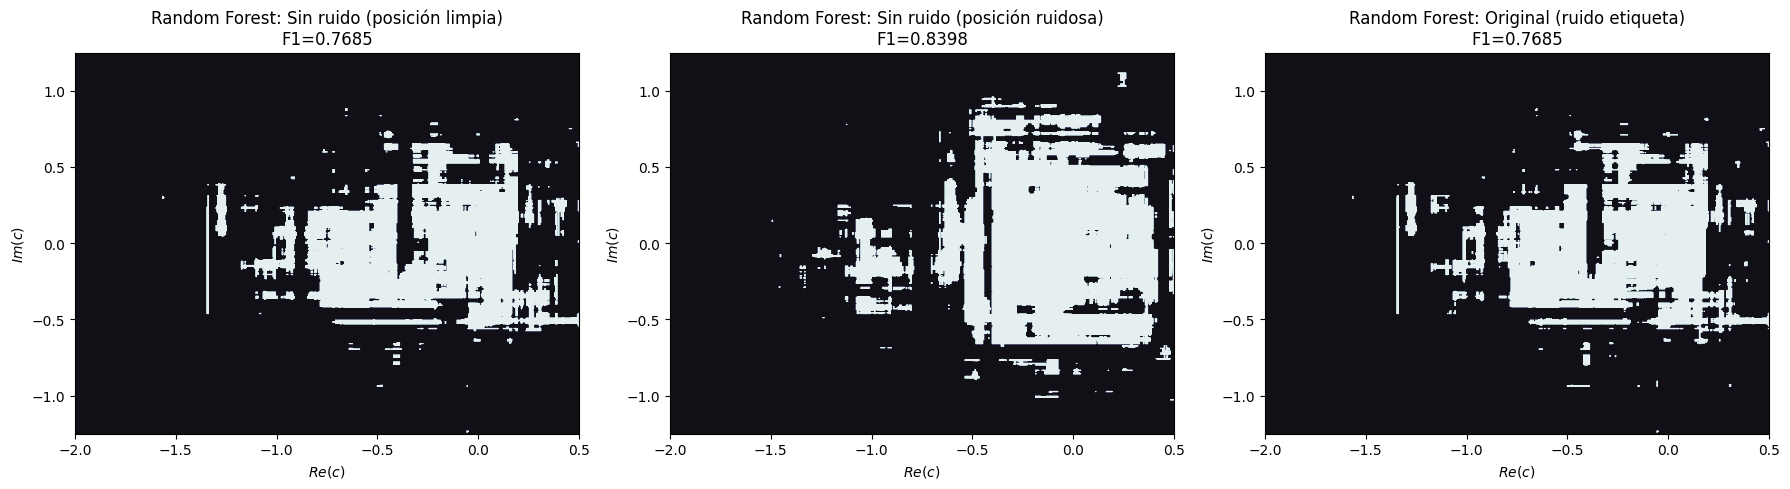

,Config,Tree_F1,Forest_F1,KNN_F1,Tree_Acc,Forest_Acc,KNN_Acc
0,Sin ruido (posición limpia),0.730132,0.768543,0.808333,0.821333,0.858667,0.877333
1,Sin ruido (posición ruidosa),0.778728,0.839752,0.817251,0.832000,0.885333,0.866667
2,Original (ruido etiqueta),0.735962,0.768543,0.808333,0.829333,0.858667,0.877333


In [72]:
# EJERCICIO 3: Eliminar ruido de etiquetas completamente

# Parte A: Con el dataset original (sin ruido)
x_clean, _ = generate_mandelbrot(w, h, Re_range, Im_range, iterations)  # Si existe
# O simplemente usar los datos SIN aplicar ruido:

mask_indices_clean = np.random.choice(total_pixels, size=1500, replace=False)
rows_clean, cols_clean = np.unravel_index(mask_indices_clean, (h, w))
x_pixels_clean = np.column_stack((cols_clean, rows_clean))

x_clean = np.zeros_like(x_pixels_clean, dtype=float)
x_clean[:, 0] = Re_range[0] + (x_pixels_clean[:, 0] / (w - 1)) * (Re_range[1] - Re_range[0])
x_clean[:, 1] = Im_range[0] + (x_pixels_clean[:, 1] / (h - 1)) * (Im_range[1] - Im_range[0])

y_clean_true = mask[x_pixels_clean[:, 1], x_pixels_clean[:, 0]]

# Dividir sin alterar etiquetas
x_train_clean, x_test_clean, y_train_clean, y_test_clean = \
    train_test_split(x_clean, y_clean_true, test_size=0.25, stratify=y_clean_true)

# Agregar solo ruido posicional (SIN ruido en etiquetas)
x_train_clean_noisy = x_train_clean + np.random.normal(0, 0.25, x_train_clean.shape)
x_train_clean_noisy[:, 0] = np.clip(x_train_clean_noisy[:, 0], 
                                     a_min=Re_range[0], a_max=Re_range[1])
x_train_clean_noisy[:, 1] = np.clip(x_train_clean_noisy[:, 1], 
                                     a_min=Im_range[0], a_max=Im_range[1])

# Comparativa: Original vs Limpio vs Limpio + posición ruidosa
configs_ex3 = {
    'Sin ruido (posición limpia)': (x_train, y_train_original),
    'Sin ruido (posición ruidosa)': (x_train_clean_noisy, y_train_clean),
    'Original (ruido etiqueta)': (x_train, y_train)
}

results_ex3 = {
    'Config': [],
    'Tree_F1': [],
    'Forest_F1': [],
    'KNN_F1': [],
    'Tree_Acc': [],
    'Forest_Acc': [],
    'KNN_Acc': []
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (config_name, (x_train_config, y_train_config)) in enumerate(configs_ex3.items()):
    print(f"\nEntrenando con: {config_name}")
    
    # Árbol
    tree_ex3 = decision_tree_pipeline.fit(x_train_config, y_train_config)
    y_pred_tree = tree_ex3.predict(x_test)
    tree_f1 = f1_score(y_test, y_pred_tree, average='macro')
    tree_acc = accuracy_score(y_test, y_pred_tree)
    
    # Random Forest  
    forest_ex3 = random_forest_pipeline.fit(x_train_config, y_train_config)
    y_pred_forest = forest_ex3.predict(x_test)
    forest_f1 = f1_score(y_test, y_pred_forest, average='macro')
    forest_acc = accuracy_score(y_test, y_pred_forest)
    
    # KNN
    knn_ex3 = knn_pipeline.fit(x_train_config, y_train_config)
    y_pred_knn = knn_ex3.predict(x_test)
    knn_f1 = f1_score(y_test, y_pred_knn, average='macro')
    knn_acc = accuracy_score(y_test, y_pred_knn)
    
    results_ex3['Config'].append(config_name)
    results_ex3['Tree_F1'].append(tree_f1)
    results_ex3['Forest_F1'].append(forest_f1)
    results_ex3['KNN_F1'].append(knn_f1)
    results_ex3['Tree_Acc'].append(tree_acc)
    results_ex3['Forest_Acc'].append(forest_acc)
    results_ex3['KNN_Acc'].append(knn_acc)
    
    print(f"  Árbol - F1: {tree_f1:.4f}, Acc: {tree_acc:.4f}")
    print(f"  RF    - F1: {forest_f1:.4f}, Acc: {forest_acc:.4f}")
    print(f"  KNN   - F1: {knn_f1:.4f}, Acc: {knn_acc:.4f}")
    
    # Visualizar frontera
    DecisionBoundaryDisplay.from_estimator(
        forest_ex3, x_test,
        cmap=plt.cm.bone,
        response_method="predict",
        ax=axes[idx],
        grid_resolution=1000,
        xlabel='$Re(c)$',
        ylabel='$Im(c)$'
    )
    axes[idx].set_xlim(*Re_range)
    axes[idx].set_ylim(*Im_range)
    axes[idx].set_title(f'Random Forest: {config_name}\nF1={forest_f1:.4f}')

plt.tight_layout()
plt.show()

# Tabla de resultados
df_ex3 = pd.DataFrame(results_ex3)
display(df_ex3)